In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Processing

## Loading Files

In [2]:
def string_to_tuple(tuple_string):
    return (int(tuple_string[0]), int(tuple_string[1]))

def pattern_string_to_tuple_list(pattern_string):
    return sorted([string_to_tuple(s) for s in [c.replace('[', '').replace(';','').replace(']','').replace(',','') for c in pattern_string.split(' ')]])

def patterns_from_txt(filepath) -> list[list[tuple[int,int]]]:
    patterns = []
    with open(filepath, 'r') as file:
        lines = file.readlines()
        for line in lines:
            patterns.append(pattern_string_to_tuple_list(line))
    return patterns

Load all stats.csv files into their respective dataframes, load pattern int tuple lists

In [3]:
ind_dataframes:list[pd.DataFrame] = [] 
pattern_lists:list[list[tuple[int,int]]] = []
N_TOTAL_BATCHES = 10
TOTAL_BATCHES = [6, 7, 8, 9, 10]
for i in range(N_TOTAL_BATCHES):
    ind_dataframes.append(pd.read_csv(f'stats_{i+1}.csv'))
    pattern_lists.append(patterns_from_txt(f'patterns_{i+1}.txt'))


In [4]:
pattern_dicts: list[dict[int,list[tuple[int,int]]]] = []
for i in range(N_TOTAL_BATCHES):
    pattern_dicts.append(dict())
    for i_p, pattern in enumerate(pattern_lists):
        pattern_dicts[i][i_p] = pattern

Create new "processed" dataframes 

In [5]:
for i in range(N_TOTAL_BATCHES):
    ind_dataframes[i]['original_pattern'] = [pattern_string_to_tuple_list(s) for s in ind_dataframes[i]['original_pattern']]
    ind_dataframes[i]['OP_i'] = [pattern_lists[i].index(s) for s in ind_dataframes[i]['original_pattern']]

for each batch: create dict where index -> sucess rate

# Data Analysis

for batches 1, 2, 5: plot success rate for each pattern in function of index

In [6]:
success_dicts: list[dict[int,float]] = []
for i in range(N_TOTAL_BATCHES):
    success_dicts.append(dict())
    for i_pattern in range(20):
        current_slice_df = ind_dataframes[i][ind_dataframes[i]['OP_i'] == i_pattern]
        success_dicts[i][i_pattern] = len(current_slice_df[current_slice_df['reconstr_success'] == True]) / len(current_slice_df)

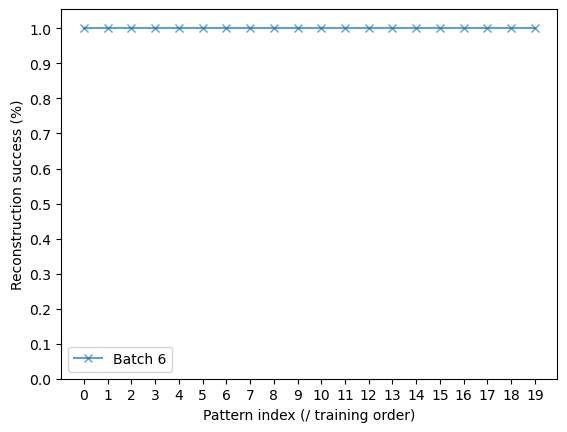

In [20]:
for i in [5]:
    plt.plot(range(20), [success_dicts[i][i_p] for i_p in range(20)], label=f'Batch {i+1}', marker='x', alpha=0.7)
plt.xlabel('Pattern index (/ training order)')
plt.xticks(np.arange(0, 20, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylabel('Reconstruction success (%)')
plt.legend()
plt.show()

for each batch: print batch total success rate

In [8]:
for i in range(N_TOTAL_BATCHES):
    total_success_rate = len(ind_dataframes[i][ind_dataframes[i]['reconstr_success'] == True]) / len(ind_dataframes[i])
    print(f'Average reconstruction success rate for batch {i+1} = {round(total_success_rate*100,2)}%')

Average reconstruction success rate for batch 1 = 85.26%
Average reconstruction success rate for batch 2 = 87.0%
Average reconstruction success rate for batch 3 = 77.11%
Average reconstruction success rate for batch 4 = 87.0%
Average reconstruction success rate for batch 5 = 85.0%
Average reconstruction success rate for batch 6 = 100.0%
Average reconstruction success rate for batch 7 = 96.06%
Average reconstruction success rate for batch 8 = 98.51%
Average reconstruction success rate for batch 9 = 98.51%
Average reconstruction success rate for batch 10 = 99.5%
